# Acoustic localization

Acoustic localization is a method for identifying the location of a sound-source, based on the time delays of arrival (TDOAs) between multiple time-synchronized audio recordings. This notebook outlines how you can use Opensoundscape's localization module to for acoustic localization. There are multiple steps involved in using an array of audio receivers to identify sound source locations. These include: 

1. Deploying time-synchronizable recording devices at static, known locations. 
2. Synchronizing recordings. 
3. Labeling the detections of your sound of interest in the audio. 
4. Estimating the time delays of arrival (TDOAs) of the sound of interest between multiple microphones.
5. Localizing the sound source from TDOAs.
6. Assessing the confidence of these localizations.

This notebook will focus mostly on steps 3 onwards, as the details of steps 1 and 2 depend on your choice of hardware.

## Run this tutorial

This tutorial is more than a reference! It's a Jupyter Notebook which you can run and modify on Google Colab or your own computer.

|Link to tutorial|How to run tutorial|
| :- | :- |
| [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kitzeslab/opensoundscape/blob/master/docs/tutorials/acoustic_localization.ipynb) | The link opens the tutorial in Google Colab. |
| [![Download via DownGit](https://img.shields.io/badge/GitHub-Download-teal?logo=github)](https://minhaskamal.github.io/DownGit/#/home?url=https://github.com/kitzeslab/opensoundscape/blob/master/docs/tutorials/acoustic_localization.ipynb) | The link downloads the tutorial file to your computer. Follow the [Jupyter installation instructions](https://opensoundscape.org/en/latest/installation/jupyter.html), then open the tutorial file in Jupyter. |

## Setup

### Import packages

In [42]:
# import the packages we'll use
import opensoundscape
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

### Local files setup
The files for this analysis are already prepared:

`aru_coords.csv` : Receiver positions in meters (x=east, y=north), computed from GPS coordinates
embedded in the filenames (e.g. `mic1_cx63.418681_cy10.407074`). mic1 is used as the origin (0, 0).

`detections.csv`: Binary species detections per 3-second segment for each recording, generated by
running BirdNET-Analyzer on all 4 time-synchronized audio files in `my_files/`.

`my_files/`: Four time-synchronized WAV recordings from microphones placed around Trondheim, Norway.

In [43]:
# Audio files are already in my_files/ and coordinates are embedded in the filenames.
# aru_coords.csv has been generated from the GPS coordinates (converted to meters, relative to mic1).
# detections.csv has been generated by running BirdNET on all 4 audio files.
print("Using local files in my_files/ — no download needed.")

Using local files in my_files/ — no download needed.


## Read in receiver coordinates

Our pipeline begins with a set of time-synchronized audio files, one from each receiver (ARU).
The GPS coordinates (latitude/longitude) were embedded in the filenames and converted to meters using:

- `x` (east–west) = `(lon − lon_ref) × 111320 × cos(lat_ref)`
- `y` (north–south) = `(lat − lat_ref) × 111320`

mic1 is used as the origin (0, 0). All four microphones are within ~70m of each other near Trondheim, Norway (63.42°N, 10.41°E).

We use this information to initialize a `SynchronizedRecorderArray` object.

In [44]:
aru_coords = pd.read_csv(
    "aru_coords.csv", index_col=0
)  # a dataframe wih index "/path/to/audio/file" and columns "x" and "y" coordinates of the ARU
aru_coords

,x,y
my_files/mic1_cx63.418681_cy10.407074_synced.WAV,0.0000,0.0000
my_files/mic2_cx63.418972_cy10.406313_synced.WAV,-37.9070,32.3941
my_files/mic3_cx63.419278_cy10.406895_synced.WAV,-8.9164,66.4580
my_files/mic4_cx63.418987_cy10.407657_synced.WAV,29.0404,34.0639


In [45]:
# initialize a SynchronizedRecorderArray with the ARU coordinates
from opensoundscape.localization import SynchronizedRecorderArray

array = SynchronizedRecorderArray(aru_coords)

The SynchronizedRecorderArray object we've created will now be used to localize a set of 'detections'. These are in the file `detections.csv`. They are a set of binary detections for every receiver in the array. For each time-window (in our case we used 3 second time-windows), every receiver either contains (1) or does not contain (0) our sounds of interest. These detections could be generated by using an automated classifier, like a CNN or RIBBIT (see our other tutorials for more information), or by manual listening. It's fine if multiple species are detected in the same time-window, on the same receiver. Though you should be aware that the busier the soundscape, the harder it will be for acoustic localization.

In [46]:
# load a dataframe with species detections generated by BirdNET-Analyzer
detections = pd.read_csv("detections.csv")

# Add start_timestamp column — all 4 files are synchronized and share the same recording start.
# Using a placeholder date; the exact date does not affect localization results.
import pytz
from datetime import datetime, timedelta

local_timestamp = datetime(2024, 1, 1, 12, 0, 0)
local_timezone = pytz.timezone("Europe/Oslo")
detections["start_timestamp"] = [
    local_timezone.localize(local_timestamp) + timedelta(seconds=s)
    for s in detections["start_time"]
]

# set four columns as a multi-index, to match format expected for localization
detections = detections.set_index(["file", "start_time", "end_time", "start_timestamp"])

detections.head()

Bank Swallow  \
file                                             start_time end_time start_timestamp                           
my_files/mic1_cx63.418681_cy10.407074_synced.WAV 0.0        3.0      2024-01-01 12:00:00+01:00           0.0   
                                                 3.0        6.0      2024-01-01 12:00:03+01:00           0.0   
                                                 6.0        9.0      2024-01-01 12:00:06+01:00           0.0   
                                                 9.0        12.0     2024-01-01 12:00:09+01:00           0.0   
                                                 12.0       15.0     2024-01-01 12:00:12+01:00           0.0   

                                                                                                Bar-tailed Godwit  \
file                                             start_time end_time start_timestamp                                
my_files/mic1_cx63.418681_cy10.407074_synced.WAV 0.0        3.0      2024-01-01 12:00:00+01:00                0.0   
                                                 3.0        6.0      2024-01-01 12:00:03+01:00                0.0   
                                                 6.0        9.0      2024-01-01 12:00:06+01:00                0.0   
                                                 9.0        12.0     2024-01-01 12:00:09+01:00                0.0   
                                                 12.0       15.0     2024-01-01 12:00:12+01:00                0.0   

                                                                                                Barn Swallow  \
file                                             start_time end_time start_timestamp                           
my_files/mic1_cx63.418681_cy10.407074_synced.WAV 0.0        3.0      2024-01-01 12:00:00+01:00           0.0   
                                                 3.0        6.0      2024-01-01 12:00:03+01:00           0.0   
                                                 6.0        9.0      2024-01-01 12:00:06+01:00           0.0   
                                                 9.0        12.0     2024-01-01 12:00:09+01:00           0.0   
                                                 12.0       15.0     2024-01-01 12:00:12+01:00           0.0   

                                                                                                Black Redstart  \
file                                             start_time end_time start_timestamp                             
my_files/mic1_cx63.418681_cy10.407074_synced.WAV 0.0        3.0      2024-01-01 12:00:00+01:00             0.0   
                                                 3.0        6.0      2024-01-01 12:00:03+01:00             0.0   
                                                 6.0        9.0      2024-01-01 12:00:06+01:00             0.0   
                                                 9.0        12.0     2024-01-01 12:00:09+01:00             0.0   
                                                 12.0       15.0     2024-01-01 12:00:12+01:00             0.0   

                                                                                                Black Woodpecker  \
file                                             start_time end_time start_timestamp                               
my_files/mic1_cx63.418681_cy10.407074_synced.WAV 0.0        3.0      2024-01-01 12:00:00+01:00               0.0   
                                                 3.0        6.0      2024-01-01 12:00:03+01:00               0.0   
                                                 6.0        9.0      2024-01-01 12:00:06+01:00               0.0   
                                                 9.0        12.0     2024-01-01 12:00:09+01:00               0.0   
                                                 12.0       15.0     2024-01-01 12:00:12+01:00               0.0   

                                                                                              

## Localize detections
We need to set two parameters before we can try and localize these sounds. They are:

- `min_n_receivers` : The minimum number of receivers that a sound must be detected on for localization to be attempted. Must be at least n+2 to localize a point in n dimensions. If you have a dense localization grid and expect your sound to be heard on more receivers, you can increase this number and it may improve the precision of location estimates.
- `max_receiver_dist` : Time delays of arrival (TDOAs) are estimated between pairs of receivers. Only receivers within `max_receiver_dist` of each other will be used for TDOA estimation. If `max_receiver_dist`=100, then if 2 receivers >100 apart both contain detections of the same sound, a TDOA will not be estimated between them. This is useful for separating out multiple simultaneous sounds at different locations if you are deploying a large array.

In [47]:
# parameters for localization
# We have exactly 4 receivers; minimum for 2D localization is 4 (n+2 for n dimensions).
# NOTE: with only 4 receivers, the Gillette algorithm converges to a degenerate solution
# near the array centroid. Use 'least_squares' instead.
min_n_receivers = 4
max_receiver_dist = 100  # maximum distance between receivers (all mics are within ~70m)
position_estimates = array.localize_detections(
    detections,
    min_n_receivers=min_n_receivers,
    max_receiver_dist=max_receiver_dist,
    localization_algorithm="least_squares",
)

In [48]:
#print the size of position_estimates
print(len(position_estimates))
print(position_estimates)

56
[PositionEstimate([24.9472747  25.84987771]), PositionEstimate([25.79777134 25.86922911]), PositionEstimate([23.72127036 27.21214898]), PositionEstimate([24.15728885 26.51111603]), PositionEstimate([24.76086539 26.43864742]), PositionEstimate([25.85413236 26.43054292]), PositionEstimate([23.8205169  27.80378681]), PositionEstimate([24.32364769 26.87590335]), PositionEstimate([25.95861688 26.59451114]), PositionEstimate([27.51354561 26.51524414]), PositionEstimate([24.71316593 28.20558901]), PositionEstimate([25.37966391 27.09436972]), PositionEstimate([20.30103343 32.88298942]), PositionEstimate([44.7677844 37.9083125]), PositionEstimate([37.53343081 50.74190137]), PositionEstimate([269.14525345  13.90983799]), PositionEstimate([26.17978275 38.83868156]), PositionEstimate([15.54685209 33.57907018]), PositionEstimate([-25.22227109  19.46145552]), PositionEstimate([ 6.02458589 37.56915656]), PositionEstimate([25.20462915 41.59439792]), PositionEstimate([30.36524051 44.95399762]), Posi

The method `array.localize_detections` returns a list of `PositionEstimate` objects. Each of these contains all the information used to estimate a location of a sound event. There is a lot of redundancy in these objects, i.e. for any given individual sound-event, we expect there to be multiple `PositionEstimate` objects, each with their own estimate of the position. Here's an outline for how these SpatialEvents are generated. 

For every receiver within a time-window that has a detection, we:

- Choose one receiver with a detection to be the central 'reference receiver'. Every other receiver that also has a detection of the same sound class, and is within `max_receiver_dist` of this reference receiver will  be included in the `PositionEstimate` object. The reference receiver will be the first receiver in the list of `receiver_files` stored in the `PositionEstimate.receiver_files` attribute.
- Cross-correlation is used to estimate the TDOA between the reference receiver, and all the other receivers included in the `PositionEstimate` object. The cross-correlations, and TDOAs are saved as the attributes `PositionEstimate.cc_maxs` and `PositionEstimate.tdoas`.
- A localization algorithm finds a solution given the TDOAs, and estimates the location of the sound source. This is saved in the `PositionEstimate.location_estimate` attribute.

In this way, each SpatialEvent provides an estimate of the sound source location, based on the TDOAs estimated against a different reference receiver. There are multiple SpatialEvents even for the same single sound-event, because we can estimate the location trying to use multiple different receivers as the central 'reference receiver'.

Let's take a look at some of the attributes of these objects below - using the first `PositionEstimate` object as an example.

In [49]:
example = position_estimates[3]
print(f"The start time of the detection: {example.start_timestamp}")
print(f"This is a detection of the class/species: {example.class_name}")
print(
    f"The duration of the time-window in which the sound was detected: {example.duration}"
)
print(f"The estimated location of the sound: {example.location_estimate}")
print(f"The receivers on which our species was detected: \n{example.receiver_files}")
print(f"The estimated time-delays of arrival: \n{example.tdoas}")
print(f"The normalized Cross-Correlation scores: \n{example.cc_maxs}")

The start time of the detection: 2024-01-01 12:00:39+01:00
This is a detection of the class/species: Common Chaffinch
The duration of the time-window in which the sound was detected: 3.0
The estimated location of the sound: [24.15728885 26.51111603]
The receivers on which our species was detected: 
['my_files/mic4_cx63.418987_cy10.407657_synced.WAV'
 'my_files/mic1_cx63.418681_cy10.407074_synced.WAV'
 'my_files/mic2_cx63.418972_cy10.406313_synced.WAV'
 'my_files/mic3_cx63.419278_cy10.406895_synced.WAV']
The estimated time-delays of arrival: 
[0.         0.07685064 0.15897564 0.12203814]
The normalized Cross-Correlation scores: 
[1.         0.02771308 0.02153259 0.02488721]


Visualize the estimated position from this SpatialEvent

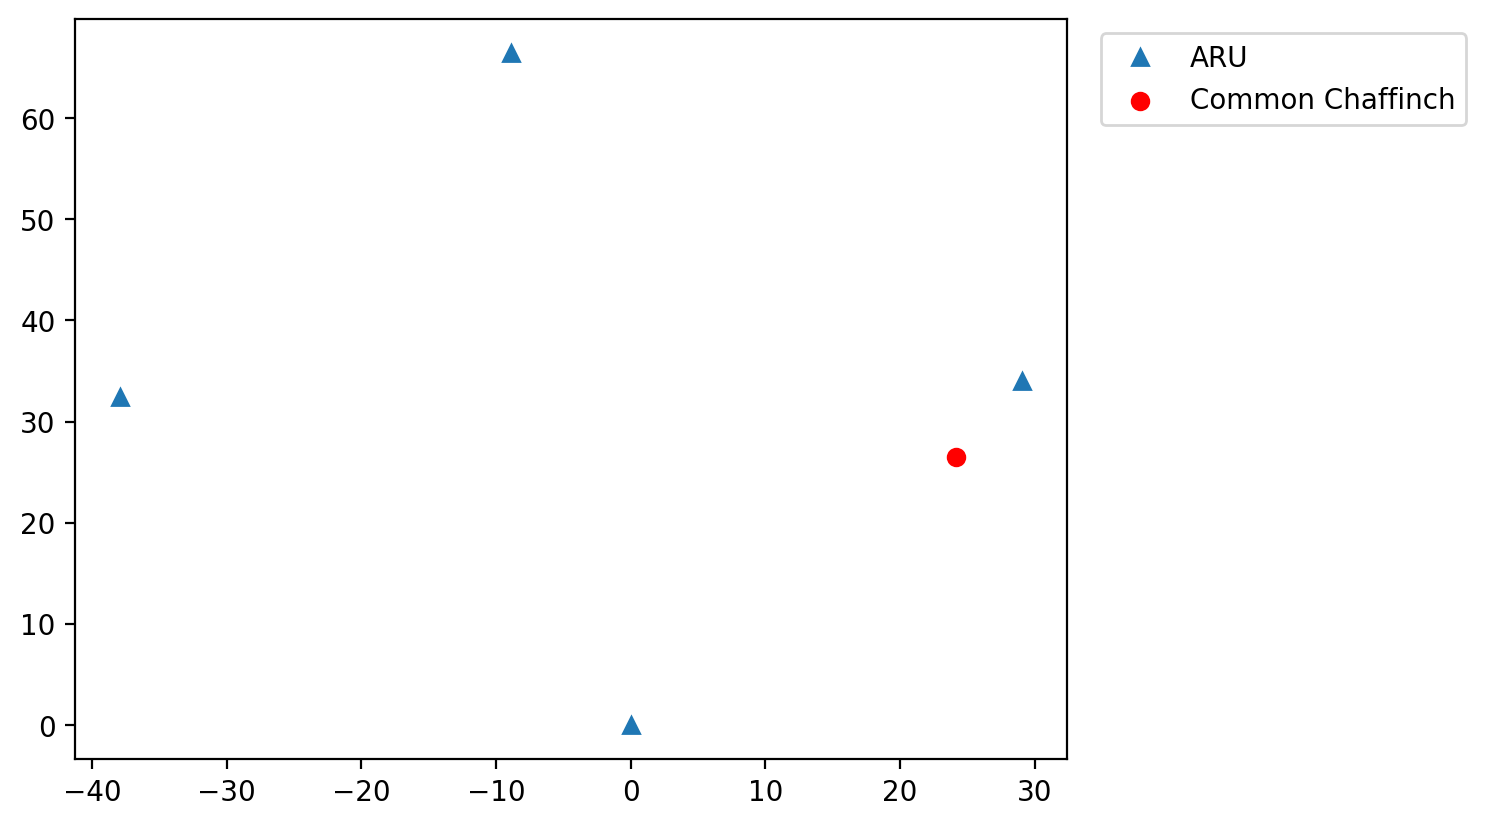

In [50]:
plt.plot(aru_coords["x"], aru_coords["y"], "^", label="ARU")
plt.scatter(
    x=example.location_estimate[0],
    y=example.location_estimate[1],
    color="red",
    label=f"{example.class_name}",
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Check if cross correlation estimated the correct tdoa values by checking for alignment of the signal in the audio clips after offsetting by tdoa:

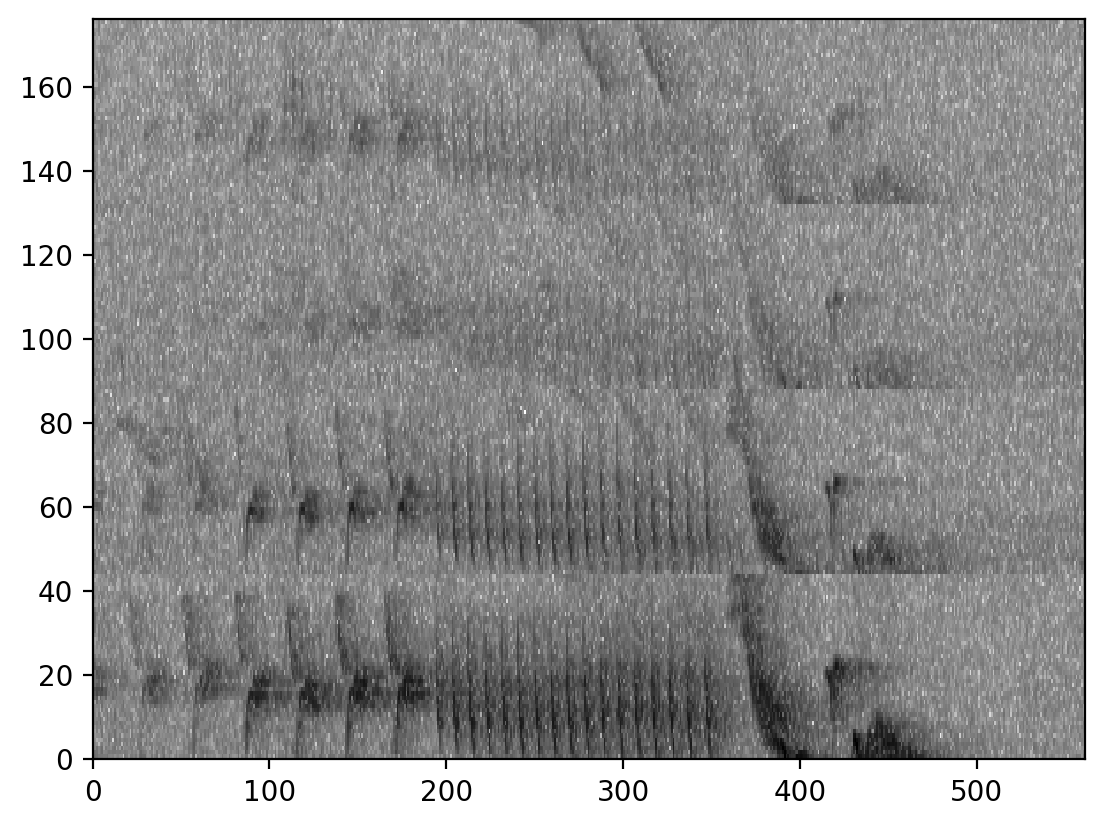

In [51]:
from opensoundscape import Spectrogram

audio_segments = example.load_aligned_audio_segments()
specs = [Spectrogram.from_audio(a).bandpass(3000, 7000) for a in audio_segments]
plt.pcolormesh(np.vstack([s.spectrogram for s in specs]), cmap="Greys")

The target sound may or may not be aligned in time across the spectrograms. If cross-correlation failed,
the signals will not line up — typically because of competing foreground sounds or noise.

We can filter out such errors by checking the residuals of the localization algorithm: the difference
between expected distances based on the position estimate and the distances implied by the TDOAs.
A root-mean-square residual >5m suggests a poor localization.

In [52]:
example.residual_rms

np.float64(0.81745549299725)

We have multiple position estimates for the same sound event — one per reference receiver.
Let's plot all location estimates for the first detected species in the first time-window where
it appears, colored by the root-mean-square residual to see how self-consistent the estimates are.

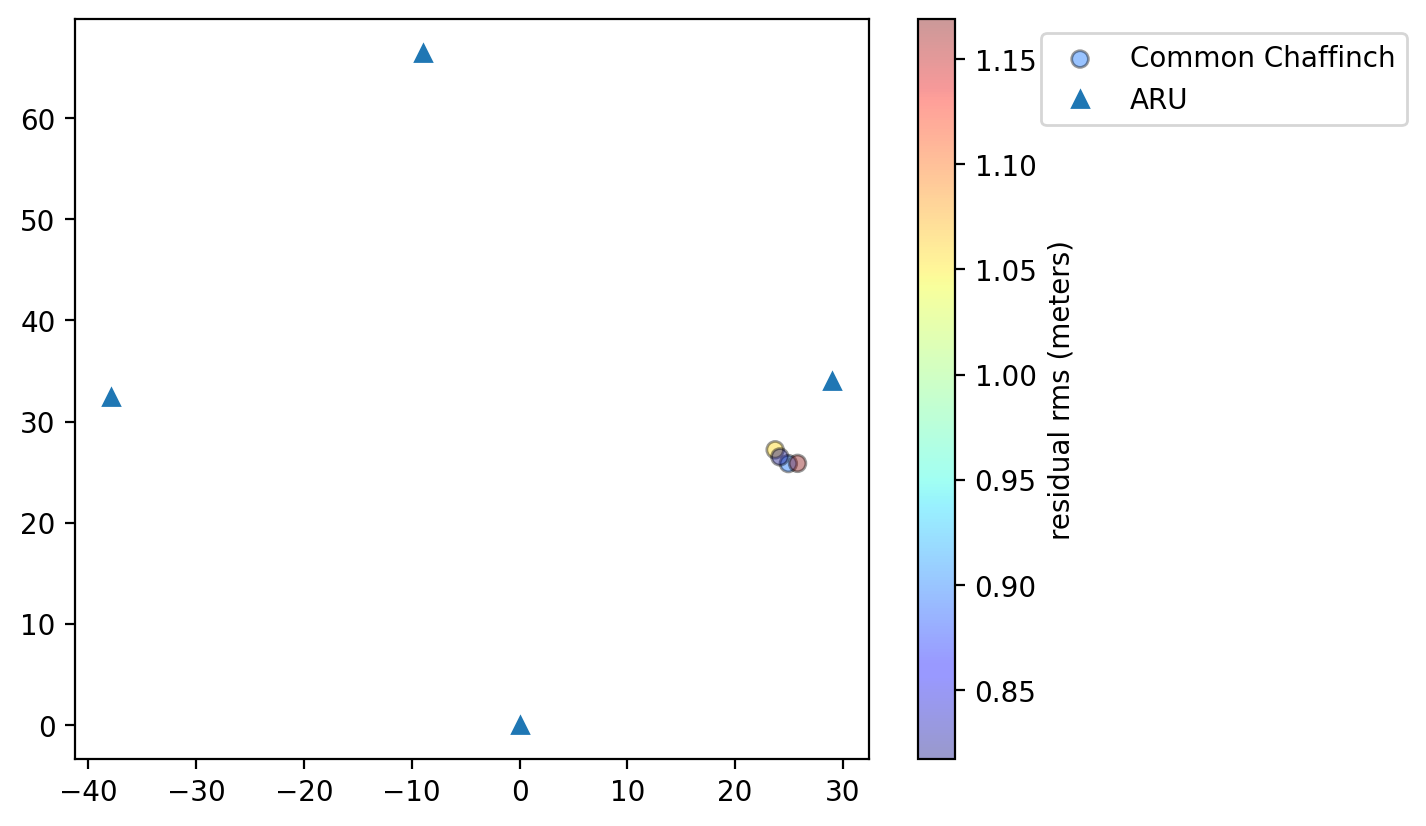

In [53]:
# get all position estimates in this time-window for the same species as example
same_species_same_window = [
    e
    for e in position_estimates
    if e.class_name == example.class_name
    and e.start_timestamp == example.start_timestamp
]
# get the x-coordinates of the estimated locations
x_coords = [e.location_estimate[0] for e in same_species_same_window]
# get the y-coordinates of the estimated locations
y_coords = [e.location_estimate[1] for e in same_species_same_window]
# get the rms of residuals per event
rms = [e.residual_rms for e in same_species_same_window]
# plot the estimated locations, colored by the residuals
plt.scatter(
    x_coords,
    y_coords,
    c=rms,
    label=example.class_name,
    alpha=0.4,
    edgecolors="black",
    cmap="jet",
)
cbar = plt.colorbar()
cbar.set_label("residual rms (meters)")
# plot the ARU locations
plt.plot(aru_coords["x"], aru_coords["y"], "^", label="ARU")
plt.legend(bbox_to_anchor=(1.2, 1), loc="upper left")

## Filter out bad localizations

We filter by `residual_rms` — the root-mean-square of TDOA residuals in meters. A value below 5m
indicates that the estimated position is consistent with the measured time delays.
We keep only low-residual position estimates and plot them.

Low-residual estimates for 'Common Chaffinch': 4


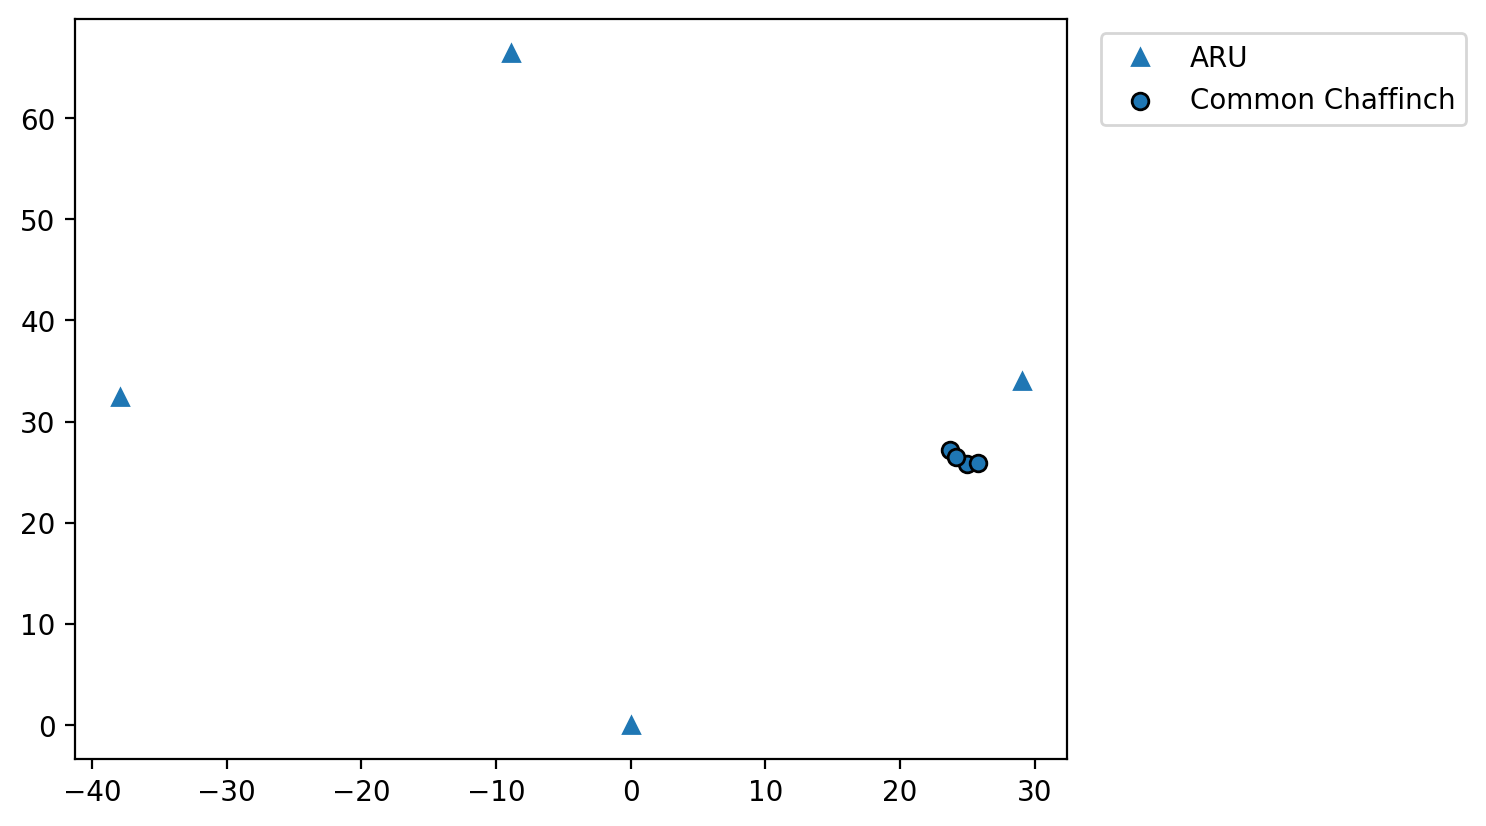

In [54]:
# filter out estimates with high residuals, keep only position estimates with <5m rms residual
# (with 'least_squares' this threshold works well, unlike 'gillette' which gave 20-40m residuals
# by converging to a degenerate solution near the array centroid)
low_rms = [
    e for e in same_species_same_window if e.residual_rms < 5
]

print(f"Low-residual estimates for '{example.class_name}': {len(low_rms)}")

# plot the ARU locations
plt.plot(aru_coords["x"], aru_coords["y"], "^", label="ARU")
# plot the estimated locations
plt.scatter(
    [e.location_estimate[0] for e in low_rms],
    [e.location_estimate[1] for e in low_rms],
    edgecolor="black",
    label=example.class_name,
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

##### Inspect alignment
Let's inspect the alignment of the target sound based on the tdoas for this localized position with low residual error

Here we can see that the Black-throated Blue warbler song at the beginning is properly aligned across all files, indicating that the cross-correlation correctly estimated time delays across recorders. 

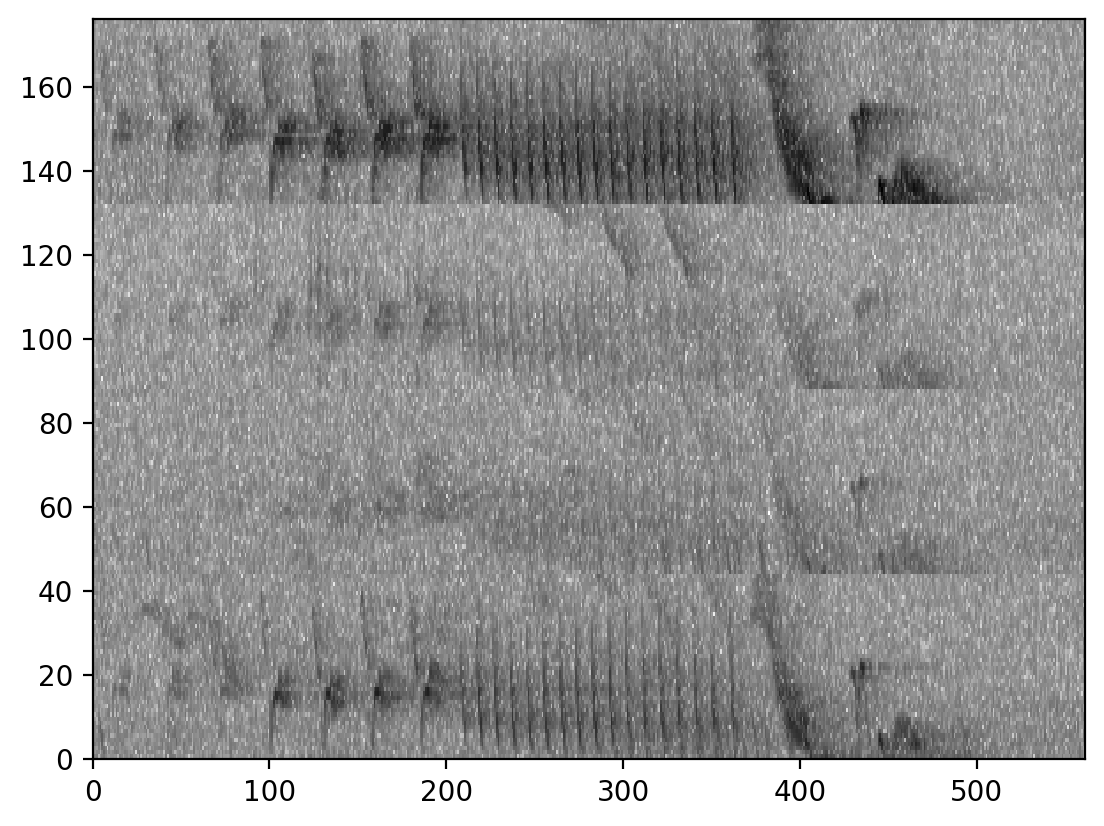

In [55]:
audio_segments = low_rms[0].load_aligned_audio_segments()
specs = [Spectrogram.from_audio(a).bandpass(3000, 7000) for a in audio_segments]
plt.pcolormesh(np.vstack([s.spectrogram for s in specs]), cmap="Greys")

## Tune localization parameters
There are also a number of parameters you might wish to experiment with, or tune to try and optimize your results. This includes only returning the localized positions with low error, like we did manually above.

- `cc_filter` : The filter applied to the signals cross-correlation. Depending on the acoustic properties of your setting, a different filter may improve TDOA estimation.
- `cc_threshold` : When estimating the TDOA, we find the time-delay that maximizes cross-correlation. You can filter out TDOAs estimated from only poorly-matching audio by increasing the `cc_threshold`. The `cc_threshold` you choose to use will also depend on the `cc_filter` used.
- `residual_threshold` : Once a location is estimated from the TDOAs, you will want to filter out positions that poorly match the observed TDOAs. Setting a low `residual_threshold` will do this.
- `bandpass_ranges` : The frequency ranges to bandpass your audio to before estimating TDOAs. This helps improve time-delay estimation.
- `localization_algorithm` : There are multiple ways to try and solve the location from a set of TDOAs. We have implemented both the Gillette & Silverman algorithm & Soundfinder (GPS) algorithm


In [56]:
# parameters for localization
min_n_receivers = 4  # exactly 4 receivers in our array
max_receiver_dist = 100  # all mics are within ~70m of each other

# Bandpass ranges (Hz) covering the main vocalization frequencies of each detected species.
# Ranges are set to the core call/song band; tighten further to improve TDOA SNR.
bandpass_ranges = {
    "Bank Swallow":              [3000, 8000],
    "Bar-tailed Godwit":         [1000, 4000],
    "Barn Swallow":              [2000, 8000],
    "Black Redstart":            [2000, 8000],
    "Black Woodpecker":          [1000, 4000],
    "Bluethroat":                [2000, 9000],
    "Bohemian Waxwing":          [5000, 9000],
    "Canada Goose":              [500,  2000],
    "Coal Tit":                  [6000, 11000],
    "Common Buzzard":            [500,  2000],
    "Common Chaffinch":          [2000, 8000],
    "Common Chiffchaff":         [4000, 8000],
    "Common Gull":               [500,  2500],
    "Common House-Martin":       [3000, 7000],
    "Common Loon":               [500,  2500],
    "Common Redpoll":            [2000, 7000],
    "Common Redstart":           [3000, 9000],
    "Common Rosefinch":          [2000, 7000],
    "Common Scoter":             [500,  2000],
    "Common Swift":              [3000, 8000],
    "Dunlin":                    [2000, 6000],
    "Dunnock":                   [2000, 8000],
    "Eurasian Blackbird":        [2000, 7000],
    "Eurasian Blackcap":         [2000, 8000],
    "Eurasian Blue Tit":         [5000, 12000],
    "Eurasian Coot":             [500,  2000],
    "Eurasian Dotterel":         [2000, 5000],
    "Eurasian Jay":              [1000, 5000],
    "Eurasian Moorhen":          [500,  3000],
    "Eurasian Nuthatch":         [2000, 8000],
    "Eurasian Pygmy-Owl":        [1000, 4000],
    "Eurasian Siskin":           [3000, 9000],
    "Eurasian Sparrowhawk":      [2000, 6000],
    "Eurasian Treecreeper":      [5000, 9000],
    "Eurasian Woodcock":         [1000, 5000],
    "Eurasian Wren":             [3000, 9000],
    "European Greenfinch":       [2000, 7000],
    "European Pied Flycatcher":  [2000, 8000],
    "European Robin":            [2000, 8000],
    "European Stonechat":        [3000, 8000],
    "Fieldfare":                 [1000, 4000],
    "Goldcrest":                 [6000, 11000],
    "Gray Heron":                [500,  2000],
    "Gray Wagtail":              [3000, 7000],
    "Great Spotted Woodpecker":  [2000, 6000],
    "Great Tit":                 [3000, 9000],
    "Herring Gull":              [500,  2500],
    "Lesser Black-backed Gull":  [500,  2500],
    "Lesser Spotted Woodpecker": [3000, 8000],
    "Little Ringed Plover":      [2000, 6000],
    "Marsh Tit":                 [3000, 8000],
    "Mistle Thrush":             [2000, 7000],
    "Northern Goshawk":          [1000, 5000],
    "Northern Lapwing":          [1000, 4000],
    "Ortolan Bunting":           [2000, 7000],
    "Osprey":                    [1000, 4000],
    "Pine Grosbeak":             [2000, 7000],
    "Red-breasted Flycatcher":   [3000, 8000],
    "Redwing":                   [2000, 8000],
    "Reed Bunting":              [2000, 6000],
    "Ring Ouzel":                [2000, 7000],
    "Ring-necked Pheasant":      [500,  2000],
    "Ruddy Turnstone":           [2000, 5000],
    "Song Thrush":               [2000, 8000],
    "Spotted Flycatcher":        [3000, 8000],
    "Tawny Owl":                 [500,  2000],
    "Tree Pipit":                [2000, 8000],
    "Whooper Swan":              [500,  2000],
    "Wood Lark":                 [2000, 8000],
    "Wood Sandpiper":            [2000, 6000],
    "Wood Warbler":              [3000, 9000],
    "Yellowhammer":              [2000, 7000],
}

# phase transform cross-correlation
cc_filter = "phat"
# threshold for TDOA residual rms, in meters.
# With 4 receivers and least_squares, residuals are typically <5m for well-localised sounds.
residual_threshold = 10
# threshold for cross-correlation score
cc_threshold = 0.01
# NOTE: use 'least_squares' — the 'gillette' algorithm converges to the array centroid
# as a degenerate local minimum with only 4 receivers
localization_algorithm = "least_squares"

position_estimates = array.localize_detections(
    detections,
    min_n_receivers=min_n_receivers,
    max_receiver_dist=max_receiver_dist,
    localization_algorithm=localization_algorithm,
    cc_threshold=cc_threshold,
    cc_filter=cc_filter,
    residual_threshold=residual_threshold,
)

print(f"Total position estimates: {len(position_estimates)}")

Total position estimates: 30


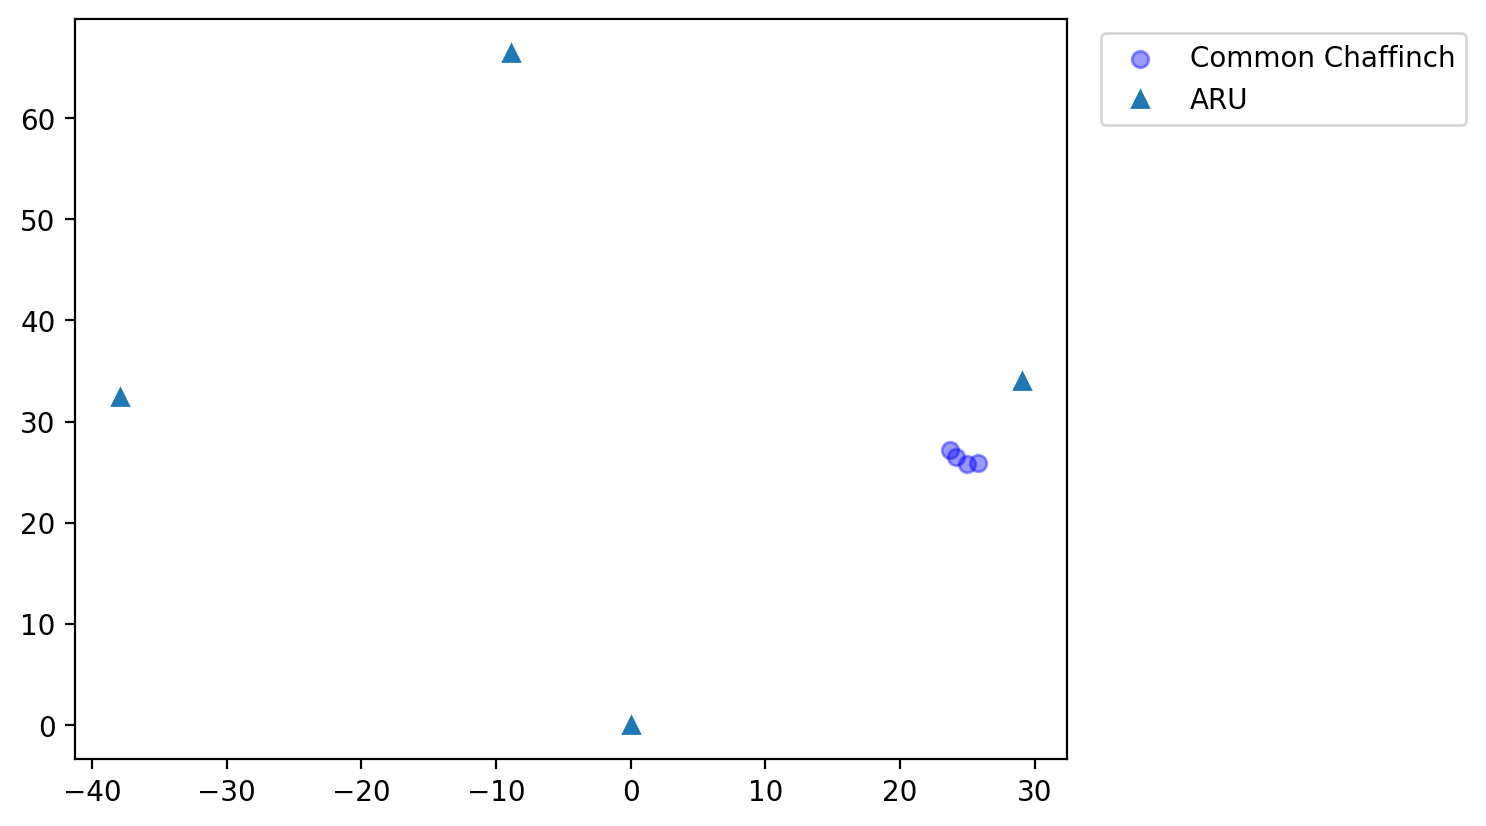

In [57]:
# get all position estimates attributed to Common Chaffinch
# (most frequently detected species on all 4 recorders simultaneously)
chaffinch_events = [
    e
    for e in position_estimates
    if e.class_name == "Common Chaffinch"
    and e.start_timestamp == example.start_timestamp
]

# get the x-coordinates of the estimated locations
x_coords = [e.location_estimate[0] for e in chaffinch_events]

# get the y-coordinates of the estimated locations
y_coords = [e.location_estimate[1] for e in chaffinch_events]

# plot the estimated locations
plt.scatter(
    x_coords, y_coords, color="blue", label="Common Chaffinch", alpha=0.4
)

# plot the ARU locations
plt.plot(aru_coords["x"], aru_coords["y"], "^", label="ARU")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

/var/folders/5v/3qtzrc9j3_bb1dtprlk50b3w0000gn/T/ipykernel_4737/154668878.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(sorted_species), 1))


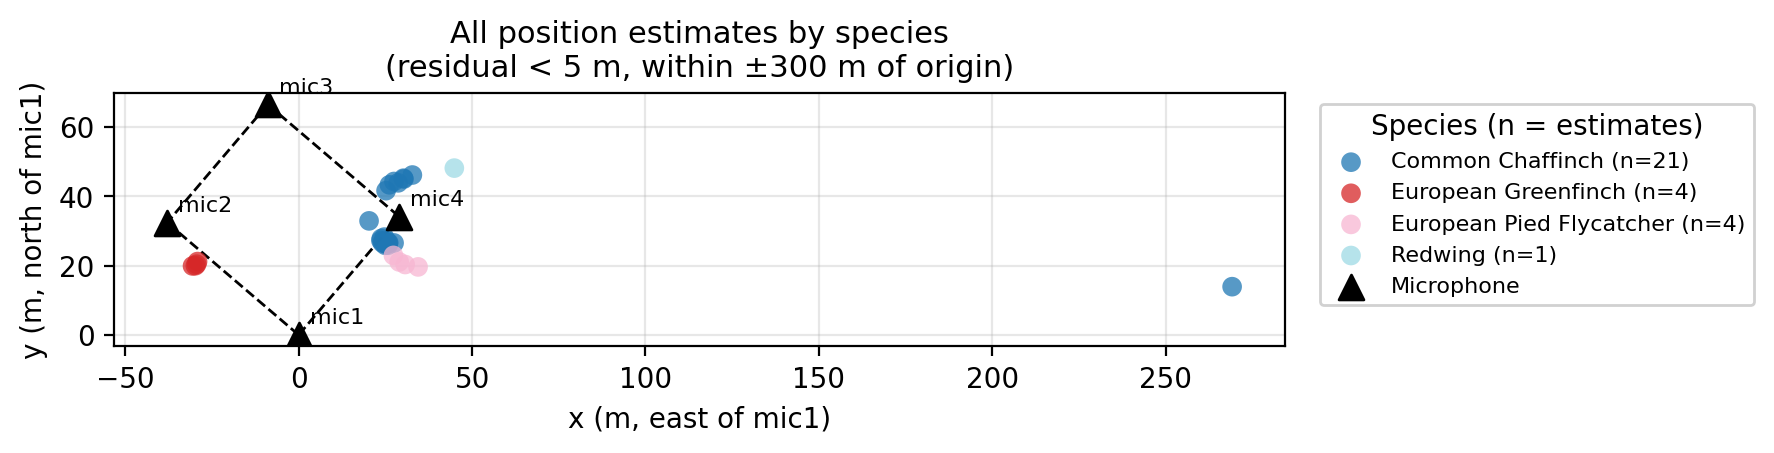


30 estimates kept across 4 species (from 30 total before filtering)


In [58]:
import matplotlib.cm as cm
from scipy.spatial import ConvexHull

# Collect all position estimates, filtering out implausible results
MAX_RESIDUAL = 5       # metres — keep only well-localised estimates
AREA_LIMIT   = 300     # metres — discard estimates that diverged far outside the array

filtered = [
    e for e in position_estimates
    if e.residual_rms is not None
    and e.residual_rms < MAX_RESIDUAL
    and abs(e.location_estimate[0]) < AREA_LIMIT
    and abs(e.location_estimate[1]) < AREA_LIMIT
]

# Group by species and sort alphabetically
from collections import defaultdict
by_species = defaultdict(list)
for e in filtered:
    by_species[e.class_name].append(e)
sorted_species = sorted(by_species.keys())

# Assign one colour per species from a qualitative colourmap
cmap = cm.get_cmap("tab20", max(len(sorted_species), 1))
species_color = {sp: cmap(i) for i, sp in enumerate(sorted_species)}

fig, ax = plt.subplots(figsize=(9, 8))

for sp in sorted_species:
    estimates = by_species[sp]
    xs = [e.location_estimate[0] for e in estimates]
    ys = [e.location_estimate[1] for e in estimates]
    ax.scatter(xs, ys,
               color=species_color[sp],
               label=f"{sp} (n={len(estimates)})",
               s=50, alpha=0.75, edgecolors="none", zorder=3)

# Draw microphone positions and array convex hull
mic_xy = aru_coords[["x", "y"]].values
hull = ConvexHull(mic_xy)
for simplex in hull.simplices:
    ax.plot(mic_xy[simplex, 0], mic_xy[simplex, 1], "k--", lw=1, zorder=2)
ax.scatter(mic_xy[:, 0], mic_xy[:, 1],
           c="black", s=80, marker="^", zorder=5, label="Microphone")
for i, row in aru_coords.iterrows():
    label = i.split("/")[-1].split("_")[0]   # "mic1", "mic2", …
    ax.annotate(label, (row["x"], row["y"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.set_xlabel("x (m, east of mic1)")
ax.set_ylabel("y (m, north of mic1)")
ax.set_title(
    f"All position estimates by species\n"
    f"(residual < {MAX_RESIDUAL} m, within ±{AREA_LIMIT} m of origin)",
    fontsize=11,
)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Legend outside the plot, sorted alphabetically
ax.legend(
    bbox_to_anchor=(1.02, 1), loc="upper left",
    fontsize=8, framealpha=0.9,
    title="Species (n = estimates)",
)
plt.tight_layout()
plt.show()

print(f"\n{len(filtered)} estimates kept across {len(sorted_species)} species "
      f"(from {len(position_estimates)} total before filtering)")

**Clean up:** Uncomment and run the following cell to delete the files you downloaded.

In [ ]:
from pathlib import Path
# Uncomment to clean up the generated CSV files (audio files in my_files/ are preserved)
# Path("aru_coords.csv").unlink()
# Path("detections.csv").unlink()